# RQ1: Functional vs Geometric Graph Evidence

## Research Question
Do functional graphs (DE/DC) outperform geometric SD for station-level 1-hour forecasting?

## Hypothesis
H1: At least one functional configuration (DE, DC, or DE+DC) yields lower test WMAPE than SD.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.notebook_reporting import (
    HEADLINE_CONTRAST_BY_RQ,
    PRIMARY_COHORT_BY_RQ,
    canon_graph_set,
    cohort_station_indices,
    load_rq_inference_geo,
    optional_csv,
    paired_station_wmape_diff,
    relative_change,
    require_csv,
)

ARTIFACT_ROOT = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
sns.set_theme(style='whitegrid', context='talk')

c:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Statistical inference (Methods)

- **H₀ / tests**: Contrasts on **mean paired per-station test WMAPE** are reported in `rq_runner/rq_hypothesis_tests.csv` (Holm-adjusted *p* within each RQ×cohort family; default α = 0.05; two-sided paired sign randomization, same helper as `train_eval`).
- **Scope**: conclusions are for this **fixed train/validation/test protocol** and test window, not automatic temporal generalization.
- **Dependence**: stations are spatially correlated; bootstrap CIs on station resamples are **approximate**. Do not relabel `train_eval_3h/station_robustness_statistics.csv` p-values as direct tests of graph-set contrasts—that file is model-vs-reference.
- **Further reading**: [docs/statistical_inference_rq.md](../docs/statistical_inference_rq.md).


### Null hypothesis (H0)

- **H0**: The mean paired per-station test WMAPE difference (`mean_delta`) between compared graph configurations equals 0 (no difference).
- Tests in `rq_runner/rq_hypothesis_tests.csv` are two-sided bootstrap paired sign randomization with Holm adjustment within each RQ×cohort (α = 0.05).
- To support a directional claim (e.g., functional < SD) we require a negative `mean_delta` together with inferential support (e.g., `reject_H0` True, `p_holm < 0.05`, or a bootstrap CI entirely below 0).

### RQ1 hypothesis tests
**Primary cohort (pre-specified)**: `all` — `is_primary_cohort` marks those rows. **train_eval** robustness CSV is model-vs-reference on one graph set; **rq_hypothesis_tests** are cross-configuration contrasts (see docs).

,cohort,contrast,H0,mean_delta,ci_lower,ci_upper,p_value,p_holm,reject_H0,n_stations_used,is_primary_cohort
1,all,SD_vs_DC,Mean paired station test WMAPE difference (DC ...,-0.039459,-0.049459,-0.027776,0.0001,0.0066,True,446,True
0,all,SD_vs_DE,Mean paired station test WMAPE difference (DE ...,0.172653,0.150478,0.190976,0.0001,0.0066,True,446,True
2,all,SD_vs_DE+DC,Mean paired station test WMAPE difference (DE+...,0.061444,0.051277,0.073947,0.0001,0.0066,True,446,True
33,dense,SD_vs_DC,Mean paired station test WMAPE difference (DC ...,-0.032259,-0.042801,-0.020056,0.0001,0.0092,True,334,False
32,dense,SD_vs_DE,Mean paired station test WMAPE difference (DE ...,0.168972,0.140137,0.191770,0.0001,0.0003,True,334,False
34,dense,SD_vs_DE+DC,Mean paired station test WMAPE difference (DE+...,0.064941,0.052282,0.079986,0.0001,0.0092,True,334,False
17,espoo,SD_vs_DC,Mean paired station test WMAPE difference (DC ...,-0.053650,-0.057181,-0.044989,0.0001,0.5002,False,103,False
16,espoo,SD_vs_DE,Mean paired station test WMAPE difference (DE ...,0.210553,0.207605,0.270534,0.0001,0.0003,True,103,False
18,espoo,SD_vs_DE+DC,Mean paired station test WMAPE difference (DE+...,0.069519,0.068764,0.094766,0.0001,0.5002,False,103,False
9,helsinki,SD_vs_DC,Mean paired station test WMAPE difference (DC ...,-0.035197,-0.046372,-0.021961,0.0001,0.0131,True,343,False


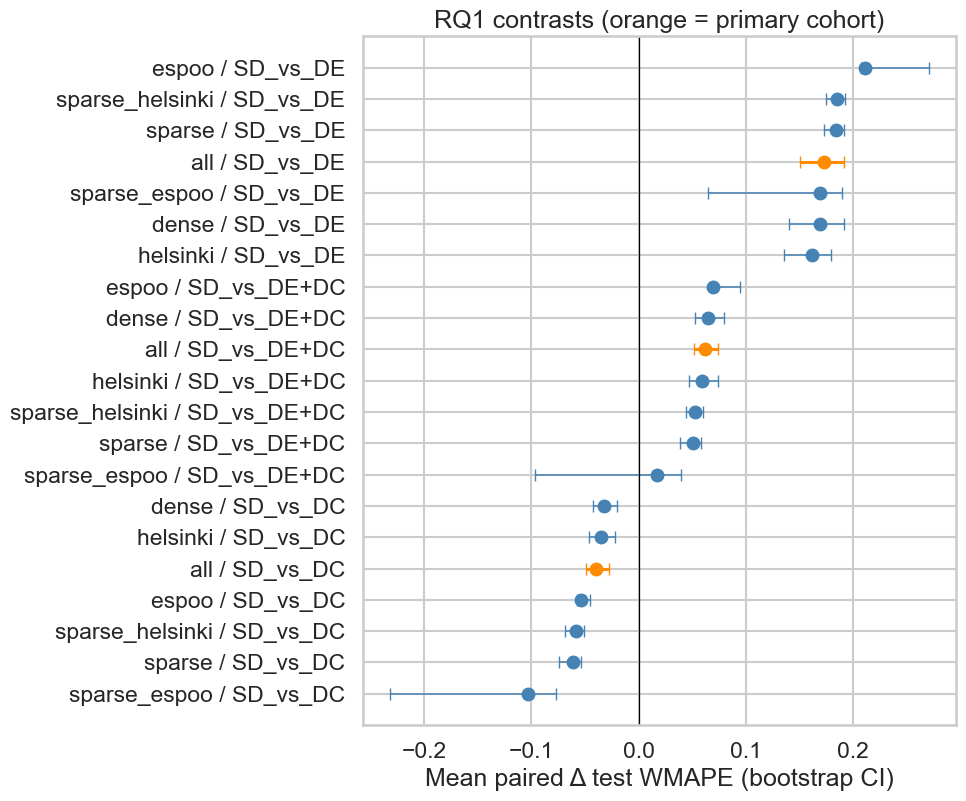

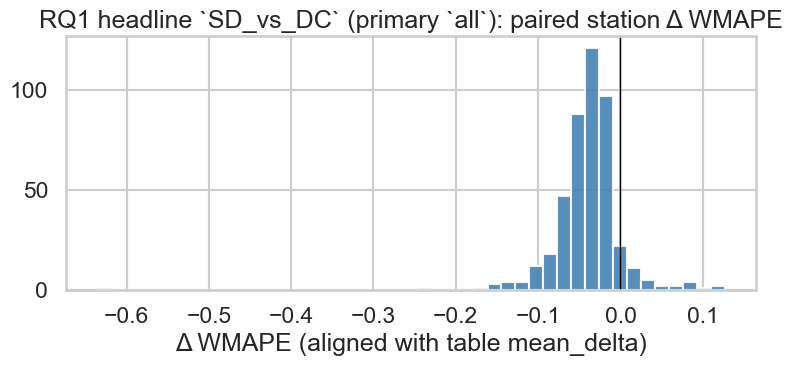

In [2]:
from IPython.display import Markdown, display

_hypothesis_path = ARTIFACT_ROOT / 'rq_runner' / 'rq_hypothesis_tests.csv'
if not _hypothesis_path.is_file():
    raise FileNotFoundError(
        f'Missing {_hypothesis_path}. After running experiment_runners, run: '
        'python -m scripts.experiments.rq_hypothesis_tests --output-dir data/artifacts/experiments/rq_runner'
    )
_rqh = pd.read_csv(_hypothesis_path)
_RQ = 'RQ1'
_rq1h = _rqh[_rqh['rq'] == _RQ].sort_values(['cohort', 'contrast']).copy()
_pc = PRIMARY_COHORT_BY_RQ[_RQ]
_rq1h['is_primary_cohort'] = _rq1h['cohort'] == _pc
display(
    Markdown(
        f'### {_RQ} hypothesis tests\n'
        f'**Primary cohort (pre-specified)**: `{_pc}` — `is_primary_cohort` marks those rows. '
        '**train_eval** robustness CSV is model-vs-reference on one graph set; **rq_hypothesis_tests** are cross-configuration contrasts (see docs).'
    )
)
_cols = [
    'cohort',
    'contrast',
    'mean_delta',
    'ci_lower',
    'ci_upper',
    'p_value',
    'p_holm',
    'reject_H0',
    'n_stations_used',
    'is_primary_cohort',
]
if 'H0' in _rq1h.columns:
    _cols = [
        'cohort',
        'contrast',
        'H0',
        'mean_delta',
        'ci_lower',
        'ci_upper',
        'p_value',
        'p_holm',
        'reject_H0',
        'n_stations_used',
        'is_primary_cohort',
    ]
display(_rq1h[_cols])

_df = _rq1h[np.isfinite(_rq1h['mean_delta'])].copy()
if not _df.empty:
    _df['label'] = _df['cohort'].astype(str) + ' / ' + _df['contrast'].astype(str)
    _df = _df.sort_values('mean_delta').reset_index(drop=True)
    y = np.arange(len(_df))
    plt.figure(figsize=(10, max(4.0, 0.35 * len(_df) + 1.0)))
    for i, row in _df.iterrows():
        color = 'darkorange' if row['is_primary_cohort'] else 'steelblue'
        elw = 2.2 if row['is_primary_cohort'] else 1.1
        lo = row['mean_delta'] - row['ci_lower']
        hi = row['ci_upper'] - row['mean_delta']
        plt.errorbar(
            [row['mean_delta']],
            [i],
            xerr=[[lo], [hi]],
            fmt='o',
            capsize=4,
            color=color,
            ecolor=color,
            elinewidth=elw,
        )
    plt.axvline(0, color='black', linewidth=0.9)
    plt.yticks(y, _df['label'])
    plt.xlabel('Mean paired Δ test WMAPE (bootstrap CI)')
    plt.title(f'{_RQ} contrasts (orange = primary cohort)')
    plt.tight_layout()
    plt.show()

_head = HEADLINE_CONTRAST_BY_RQ[_RQ]
_row = _rq1h[(_rq1h['cohort'] == _pc) & (_rq1h['contrast'] == _head)]
_exp = {'experiment_a', 'experiment_b'}
if len(_row) == 1 and _exp <= set(_row.columns):
    try:
        geo = load_rq_inference_geo(ARTIFACT_ROOT)
        idx = cohort_station_indices(
            _pc,
            train_csv=geo['train_csv'],
            graph_dir=geo['graph_dir'],
            stations_dir=geo['stations_dir'],
            sparse_quantile=geo['sparse_quantile'],
        )
        diff = paired_station_wmape_diff(
            geo['scores_dir'],
            str(_row['experiment_a'].iloc[0]),
            str(_row['experiment_b'].iloc[0]),
            idx,
        )
        if diff.size:
            plt.figure(figsize=(8, 4))
            nb = min(45, max(12, int(np.sqrt(diff.size)) * 3))
            plt.hist(diff, bins=nb, color='steelblue', edgecolor='white', alpha=0.9)
            plt.axvline(0, color='black', linewidth=1)
            plt.title(f'{_RQ} headline `{_head}` (primary `{_pc}`): paired station Δ WMAPE')
            plt.xlabel('Δ WMAPE (aligned with table mean_delta)')
            plt.tight_layout()
            plt.show()
    except Exception as exc:
        print('Skipping headline distribution plot:', exc)


In [3]:
rq_results = require_csv('rq_runner/results.csv', required_columns=('rq', 'aggregation', 'graph_set', 'model', 'test_wmape'))
rq1_rows = rq_results.filter((pl.col('rq') == 'RQ1') & (pl.col('aggregation') == 'station') & (pl.col('model') == 'graph_propagation')).to_pandas()
rq1_rows['graph_set'] = rq1_rows['graph_set'].apply(canon_graph_set)

rq_meta_path = ARTIFACT_ROOT / 'rq_runner' / 'metadata.json'
train_eval_meta_path = ARTIFACT_ROOT / 'train_eval_3h' / 'metadata.json'

provenance = pd.DataFrame([
    {'artifact': 'rq_runner/results.csv', 'exists': (ARTIFACT_ROOT / 'rq_runner' / 'results.csv').exists()},
    {'artifact': 'rq_runner/metadata.json', 'exists': rq_meta_path.exists()},
    {'artifact': 'train_eval_3h/station_robustness_statistics.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_3h' / 'station_robustness_statistics.csv').exists()},
    {'artifact': 'train_eval_3h/metadata.json', 'exists': train_eval_meta_path.exists()},
])

inclusion = pd.DataFrame([
    {'criterion': 'RQ1 rows available', 'value': int(len(rq1_rows))},
    {'criterion': 'Unique graph sets', 'value': int(rq1_rows['graph_set'].nunique())},
    {'criterion': 'Any missing test_wmape', 'value': bool(rq1_rows['test_wmape'].isna().any())},
])

provenance, inclusion

(                                          artifact  exists
 0                            rq_runner/results.csv    True
 1                          rq_runner/metadata.json    True
 2  train_eval_3h/station_robustness_statistics.csv    True
 3                      train_eval_3h/metadata.json    True,
                 criterion  value
 0      RQ1 rows available      4
 1       Unique graph sets      4
 2  Any missing test_wmape  False)

In [4]:
rq1_summary = rq1_rows.groupby('graph_set', as_index=False)['test_wmape'].mean().sort_values('test_wmape')
baseline = dict(zip(rq1_summary['graph_set'], rq1_summary['test_wmape']))
sd = baseline.get('SD')

effect_rows = []
for candidate in ('DE', 'DC', 'DE+DC'):
    value = baseline.get(candidate)
    if value is None or sd is None:
        continue
    effect_rows.append({
        'comparison': f'{candidate} vs SD',
        'candidate_test_wmape': value,
        'sd_test_wmape': sd,
        'absolute_delta': value - sd,
        'relative_delta': relative_change(value, sd),
    })

rq1_effects = pd.DataFrame(effect_rows).sort_values('absolute_delta')
rq1_summary, rq1_effects

(  graph_set  test_wmape
 0        DC    0.672800
 3        SD    0.693382
 2     DE+DC    0.801417
 1        DE    0.862879,
     comparison  candidate_test_wmape  sd_test_wmape  absolute_delta  \
 1     DC vs SD              0.672800       0.693382       -0.020582   
 2  DE+DC vs SD              0.801417       0.693382        0.108036   
 0     DE vs SD              0.862879       0.693382        0.169497   
 
    relative_delta  
 1       -0.029683  
 2        0.155810  
 0        0.244450  )

### Model Comparison: Graph Sensitivity

The table and figure below compare test WMAPE for **all four model families** across graph types.

- **Non-graph models** (lagged_linear, tree_lagged, seasonal_naive) produce *identical* WMAPE regardless of which adjacency matrix is supplied — their flat values serve as the null condition and confirm the pipeline's correctness.
- **graph_propagation** is the only model whose performance varies systematically with graph structure (CoV > 10%), making it the appropriate controlled instrument for RQ1.
- **STGNN** shows near-zero variance across graph types (CoV < 1%), confirming it learns to compensate for graph quality through its temporal attention mechanism — graph-invariance is a feature operationally, but eliminates the inferential signal needed for RQ1.

In [5]:
# ── Multi-model graph-sensitivity table ──────────────────────────────────────
rq1_all_models = rq_results.filter(
    (pl.col('rq') == 'RQ1') & (pl.col('aggregation') == 'station')
).to_pandas()
rq1_all_models['graph_set'] = rq1_all_models['graph_set'].apply(canon_graph_set)

pivot_rq1 = (
    rq1_all_models
    .pivot_table(index='model', columns='graph_set', values='test_wmape', aggfunc='mean')
    .round(4)
)
pivot_rq1.columns.name = None
pivot_rq1['CoV (%)'] = (pivot_rq1.std(axis=1) / pivot_rq1.mean(axis=1) * 100).round(1)
pivot_rq1 = pivot_rq1.sort_values('CoV (%)', ascending=False)

# ── STGNN graph-invariance (M3.1 single-graph) ───────────────────────────────
stgnn_milestones_path = ARTIFACT_ROOT / 'stgnn_milestones' / 'milestone_results.csv'
stgnn_inv = pd.DataFrame()
if stgnn_milestones_path.exists():
    stgnn_df = pd.read_csv(stgnn_milestones_path)
    m31 = stgnn_df[stgnn_df['milestone'] == 'M3.1_single_graph'].copy()
    stgnn_inv = (
        m31.pivot_table(index='aggregation', columns='graph_set', values='test_wmape', aggfunc='mean')
        .round(4)
    )
    stgnn_inv.columns.name = None
    stgnn_inv['CoV (%)'] = (stgnn_inv.std(axis=1) / stgnn_inv.mean(axis=1) * 100).round(2)
    stgnn_inv.index = ['STGNN ' + idx for idx in stgnn_inv.index]
    print('STGNN graph-sensitivity (M3.1 single-graph, inference communities):')
    display(stgnn_inv)
    print()
else:
    print('stgnn_milestones/milestone_results.csv not found.')

print('All models graph-sensitivity (RQ1, station-level):')
display(pivot_rq1)

STGNN graph-sensitivity (M3.1 single-graph, inference communities):


,ATD,DC,DE,SD,CoV (%)
STGNN community,0.267,0.2669,0.2670,0.2669,0.02
STGNN station,0.863,0.8739,0.8637,0.8633,0.61



All models graph-sensitivity (RQ1, station-level):


,DC,DE,DE+DC,SD,CoV (%)
model,,,,,
graph_propagation,0.6728,0.8629,0.8014,0.6934,11.9
lagged_linear,0.6078,0.6078,0.6078,0.6078,0.0
seasonal_naive,0.9092,0.9092,0.9092,0.9092,0.0
tree_lagged,0.6081,0.6081,0.6081,0.6081,0.0


In [6]:
robustness = optional_csv('train_eval_3h/station_robustness_statistics.csv', required_columns=('cohort', 'model', 'reference_model', 'test_station_wmape_mean', 'test_station_wmape_ci_lower', 'test_station_wmape_ci_upper', 'paired_sign_permutation_pvalue'))

if robustness is None:
    print('Uncertainty artifact unavailable: train_eval_3h/station_robustness_statistics.csv')
    rq1_uncertainty = pd.DataFrame()
else:
    rq1_uncertainty = robustness.filter((pl.col('model') == 'graph_propagation')).select([
        'cohort',
        'test_station_wmape_mean',
        'test_station_wmape_ci_lower',
        'test_station_wmape_ci_upper',
        'paired_sign_permutation_pvalue',
    ]).sort('cohort').to_pandas()

rq1_uncertainty

,cohort,test_station_wmape_mean,test_station_wmape_ci_lower,test_station_wmape_ci_upper,paired_sign_permutation_pvalue
0,all,0.915005,0.889250,0.942560,1.0
1,dense,0.837056,0.811775,0.862723,1.0
2,espoo,1.052703,1.010331,1.095922,1.0
3,helsinki,0.873656,0.845338,0.904016,1.0
4,sparse,1.147461,1.096519,1.198672,1.0
5,sparse_espoo,1.323027,1.227513,1.389999,1.0
6,sparse_helsinki,1.137524,1.086606,1.190768,1.0


In [7]:
sensitivity = optional_csv('train_eval_3h/sensitivity_summary.csv', required_columns=('sensitivity_axis', 'scope', 'aggregation', 'model', 'setting', 'metric', 'delta_vs_reference'))

if sensitivity is None:
    print('Sensitivity artifact unavailable: train_eval_3h/sensitivity_summary.csv')
    rq1_sensitivity = pd.DataFrame()
else:
    rq1_sensitivity = sensitivity.filter((pl.col('model') == 'graph_propagation') & (pl.col('sensitivity_axis').is_in(['hyperparameter', 'resolution']))).sort(['scope', 'setting']).to_pandas()

rq1_sensitivity.head(20)

,sensitivity_axis,scope,aggregation,model,setting,metric,value,reference_value,delta_vs_reference
0,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.0,validation_wmape,0.770632,0.261439,0.509193
1,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.0,validation_wmape,0.742196,0.700645,0.041551
2,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.05,validation_wmape,0.696481,0.261439,0.435042
3,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.05,validation_wmape,0.727468,0.700645,0.026823
4,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.1,validation_wmape,0.633104,0.261439,0.371664
5,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.1,validation_wmape,0.716410,0.700645,0.015765
6,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.15,validation_wmape,0.578740,0.261439,0.317300
7,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.15,validation_wmape,0.708563,0.700645,0.007918
8,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.2,validation_wmape,0.531939,0.261439,0.270499
9,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.2,validation_wmape,0.703535,0.700645,0.002890


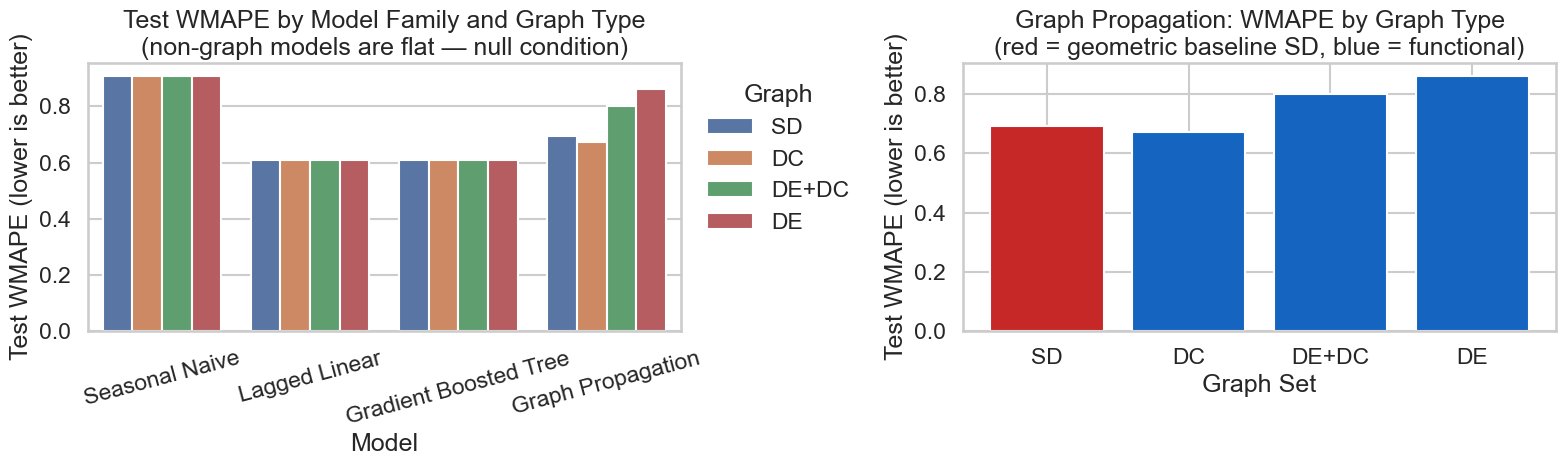

In [8]:
MODEL_ORDER = ['seasonal_naive', 'lagged_linear', 'tree_lagged', 'graph_propagation']
MODEL_LABELS = {
    'seasonal_naive': 'Seasonal Naive',
    'lagged_linear': 'Lagged Linear',
    'tree_lagged': 'Gradient Boosted Tree',
    'graph_propagation': 'Graph Propagation',
}
GRAPH_ORDER_RQ1 = ['SD', 'DC', 'DE+DC', 'DE']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: all models × graph type — shows flat non-graph baselines and varying graph_propagation
plot_all = rq1_all_models[rq1_all_models['model'].isin(MODEL_ORDER)].copy()
plot_all['model_label'] = plot_all['model'].map(MODEL_LABELS).fillna(plot_all['model'])
plot_all['graph_set'] = pd.Categorical(plot_all['graph_set'], categories=GRAPH_ORDER_RQ1, ordered=True)
sns.barplot(
    data=plot_all.sort_values('graph_set'),
    x='model_label', y='test_wmape', hue='graph_set',
    order=[MODEL_LABELS[m] for m in MODEL_ORDER],
    hue_order=GRAPH_ORDER_RQ1,
    palette='deep', ax=axes[0],
)
axes[0].set_title('Test WMAPE by Model Family and Graph Type\n(non-graph models are flat — null condition)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Test WMAPE (lower is better)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Graph', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# Panel 2: graph_propagation focused — SD (geometric baseline) vs functional graphs
gp_plot = rq1_summary.copy()
gp_plot['graph_set'] = pd.Categorical(gp_plot['graph_set'], categories=GRAPH_ORDER_RQ1, ordered=True)
bar_colors = ['#C62828' if g == 'SD' else '#1565C0' for g in gp_plot.sort_values('graph_set')['graph_set']]
axes[1].bar(
    range(len(gp_plot)),
    gp_plot.sort_values('graph_set')['test_wmape'],
    color=bar_colors,
)
axes[1].set_xticks(range(len(gp_plot)))
axes[1].set_xticklabels(GRAPH_ORDER_RQ1)
axes[1].set_title('Graph Propagation: WMAPE by Graph Type\n(red = geometric baseline SD, blue = functional)')
axes[1].set_xlabel('Graph Set')
axes[1].set_ylabel('Test WMAPE (lower is better)')

plt.tight_layout()
plt.show()

## Threats To Validity (RQ1)

- RQ1 conclusions are conditional on graph_propagation as the testing instrument. The STGNN is deliberately excluded from RQ1 inference because its temporal attention mechanism renders it graph-invariant (CoV < 1% across graph types), eliminating the inferential signal. This is not a limitation but a design choice: graph_propagation's direct adjacency propagation isolates graph structure as the sole variable.
- Non-graph baselines (tree_lagged, lagged_linear) outperform graph_propagation at station level (0.608 vs 0.673–0.863), confirming that graph structure alone does not guarantee the best absolute performance. RQ1 tests *which graph structure is more informative* within graph-based propagation, not whether graph propagation is superior overall.
- Robustness p-values are model-vs-reference summaries from train_eval and are not direct between-graph-set tests.
- External validity remains bounded by Helsinki-Espoo split and demand dynamics.

In [9]:
# Assess RQ1 using pre-registered contrasts (headline in primary cohort)
def assess_rq_from_contrasts(_rqh, RQ, alpha=0.05):
    pc = PRIMARY_COHORT_BY_RQ[RQ]
    head = HEADLINE_CONTRAST_BY_RQ[RQ]
    sub = _rqh[(_rqh['cohort'] == pc) & (_rqh['contrast'] == head)]
    if len(sub) != 1:
        return pd.DataFrame([{'rq': RQ, 'claim_status': 'insufficient_data', 'rationale': f'Headline contrast {head} not found in primary cohort {pc}'}])
    row = sub.iloc[0]
    md = float(row['mean_delta']) if np.isfinite(row.get('mean_delta', np.nan)) else np.nan
    # Extract available inferential fields
    p_cluster = float(row['p_cluster']) if ('p_cluster' in _rqh.columns and np.isfinite(row.get('p_cluster', np.nan))) else np.nan
    p_holm = float(row['p_holm']) if ('p_holm' in _rqh.columns and np.isfinite(row.get('p_holm', np.nan))) else np.nan
    reject = bool(row['reject_H0']) if 'reject_H0' in _rqh.columns else False
    ci_low = float(row['ci_lower']) if ('ci_lower' in _rqh.columns and np.isfinite(row.get('ci_lower', np.nan))) else np.nan
    ci_up = float(row['ci_upper']) if ('ci_upper' in _rqh.columns and np.isfinite(row.get('ci_upper', np.nan))) else np.nan
    cluster_aware = bool(row.get('cluster_aware')) if 'cluster_aware' in _rqh.columns else False
    # Determine inferential support: prefer explicit reject_H0; otherwise prefer cluster p, then p_holm, then CI
    if 'reject_H0' in _rqh.columns:
        inferential = reject
        inferential_source = 'reject_H0' if reject else 'reject_H0_false'
    else:
        if cluster_aware and np.isfinite(p_cluster):
            inferential = p_cluster < alpha
            inferential_source = 'p_cluster'
        elif np.isfinite(p_holm):
            inferential = p_holm < alpha
            inferential_source = 'p_holm'
        elif np.isfinite(ci_low) and np.isfinite(ci_up):
            if np.isfinite(md):
                inferential = (ci_up < 0) if md < 0 else (ci_low > 0)
                inferential_source = 'ci'
            else:
                inferential = False
                inferential_source = 'ci_na'
        else:
            inferential = False
            inferential_source = 'none'
    # Decide status requiring proper direction
    if inferential and np.isfinite(md):
        if md < 0:
            status = 'supported'
        else:
            status = 'contradicted'
    else:
        status = 'mixed_or_not_supported'
    rationale = f"mean_delta={md:.6f}; inferential={inferential} (src={inferential_source}); p_holm={p_holm}; p_cluster={p_cluster}; ci=({ci_low},{ci_up}); reject_H0={reject}"
    return pd.DataFrame([{'rq': RQ, 'claim_status': status, 'rationale': rationale}])

assess_rq_from_contrasts(_rq1h, 'RQ1')

,rq,claim_status,rationale
0,RQ1,supported,mean_delta=-0.039459; inferential=True (src=re...
